In [8]:
# from google.colab import drive
# drive.mount('/content/drive')

from pathlib import Path

# Set your local project path
local_path = "C:\\Users\\naing\\MultiVacSim"

# Check if the folder exists
if Path(local_path).exists():
    print("Local folder found at:", local_path)
else:
    print("Local folder not found. Please check the path.")


Local folder found at: C:\Users\naing\MultiVacSim


In [9]:
import psutil
import os
def get_memory_usage():
    process = psutil.Process(os.getpid())
    mem_info = process.memory_info()
    ram_usage_mb = mem_info.rss / (1024 * 1024)  # Convert bytes to MB
    print(f"🔹 Current RAM Usage: {ram_usage_mb:.2f} MB")

In [10]:
# !ls "/content/drive/My Drive/"

In [11]:
# !ls "/content/drive/My Drive/Spring25_Research/data/covid"

In [12]:
import os
import pandas as pd
# Define folder path
folder_path = "C:\\Users\\naing\\MultiVacSim\\data\\processed\\"

# List all CSV files in the folder
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

# Dictionary to store column mappings
column_mappings = {}

# Read each CSV and extract column names
for csv_file in csv_files:
    file_path = os.path.join(folder_path, csv_file)
    try:
        df = pd.read_csv(file_path, nrows=40)  # Read only first few rows to get columns
        column_mappings[csv_file] = list(df.columns)
    except Exception as e:
        column_mappings[csv_file] = f"Error reading file: {e}"

# Display extracted column mappings
# Convert to DataFrame and display
column_mappings_df = pd.DataFrame.from_dict(column_mappings, orient="index").T
column_mappings_df

""


In [13]:
import pandas as pd

# Define uploaded file paths
file_paths = {
    "covid_vaccination_data": "C:\\Users\\naing\\MultiVacSim\\data\\processed\\covid\\covid_vaccination_data_s.csv",
    "covid_hospitalization_data": "C:\\Users\\naing\\MultiVacSim\\data\\processed\\covid\\covid_hospitalization_data_s.csv",
    "covid_mortality_data": "C:\\Users\\naing\\MultiVacSim\\data\\processed\\covid\\covid_mortality_data_s.csv",
    "covid_trend_data": "C:\\Users\\naing\\MultiVacSim\\data\\processed\\covid\\covid_trend_data_s.csv",
    "flu_vaccination_data": "C:\\Users\\naing\\MultiVacSim\\data\\processed\\flu\\flu_vaccination_data_s.csv",
    "flu_hospitalization_data": "C:\\Users\\naing\\MultiVacSim\\data\\processed\\flu\\flu_hospitalization_data_s.csv",
    "flu_mortality_data": "C:\\Users\\naing\\MultiVacSim\\data\\processed\\flu\\flu_mortality_data_s.csv",
    "flu_trend_data": "C:\\Users\\naing\\MultiVacSim\\data\\processed\\flu\\flu_trend_data_s.csv",
}


# Check column names in each dataset
column_info = {}
for name, path in file_paths.items():
    try:
        df = pd.read_csv(path, nrows=5)  # Load only first 5 rows for efficiency
        column_info[name] = df.columns.tolist()
    except Exception as e:
        column_info[name] = f"Error loading file: {e}"

# Display column names for verification
column_info


{'covid_vaccination_data': ['COVID-19_Season',
  'Week_ID',
  'Current_Season_Week_Ending_Label',
  'MMWR_Week_Order',
  'MMWR_Year',
  'MMWR_Week',
  'MMWR_Day',
  'Setting',
  'Doses',
  'Cumulative_Doses',
  'Location_and_Flu_Season_Order',
  'Current_Through',
  'Age_Group',
  'current_season',
  'Month',
  'Numerator',
  'Population',
  'Jurisdiction',
  'Estimate',
  'Age_group_label',
  'Legend',
  'Child or adult',
  'Week Ending',
  'Enrollment Date',
  'As of date',
  'Race and ethnicity',
  'comparison_type',
  'week_ending',
  'current_season_week_ending_label',
  'comparison_group_1',
  'comparison_group_2',
  'comparison_group1_point_estimate',
  'comparison_group2_point_estimate',
  'estimate_difference',
  'difference_estimate_lower_95_ci',
  'difference_estimate_upper_95_ci',
  'significant_at_95_pct',
  'comparison_group_1_sort_order',
  'comparison_group_2_sort_order'],
 'covid_hospitalization_data': ['State',
  'Season',
  '_WeekendDate',
  'AgeCategory_Legend',
  '

In [25]:
import numpy as np 
import pandas as pd
import dask.dataframe as dd

def standardize_location_column(df):
    for col in df.columns:
        if col.lower() in ["state", "jurisdiction", "jurisdiction_residence", "geographic name"]:
            df = df.rename(columns={col: "state"})
    
    # Ensure state column is always of type string
    if "state" in df.columns:
        df["state"] = df["state"].astype(str)
    
    return df


# Define file paths
file_paths = {
    "covid_vaccination_data": "C:\\Users\\naing\\MultiVacSim\\data\\processed\\covid\\covid_vaccination_data_s.csv",
    "covid_hospitalization_data": "C:\\Users\\naing\\MultiVacSim\\data\\processed\\covid\\covid_hospitalization_data_s.csv",
    "covid_mortality_data": "C:\\Users\\naing\\MultiVacSim\\data\\processed\\covid\\covid_mortality_data_s.csv",
    "covid_trend_data": "C:\\Users\\naing\\MultiVacSim\\data\\processed\\covid\\covid_trend_data_s.csv",
    "flu_vaccination_data": "C:\\Users\\naing\\MultiVacSim\\data\\processed\\flu\\flu_vaccination_data_s.csv",
    "flu_hospitalization_data": "C:\\Users\\naing\\MultiVacSim\\data\\processed\\flu\\flu_hospitalization_data_s.csv",
    "flu_mortality_data": "C:\\Users\\naing\\MultiVacSim\\data\\processed\\flu\\flu_mortality_data_s.csv",
    "flu_trend_data": "C:\\Users\\naing\\MultiVacSim\\data\\processed\\flu\\flu_trend_data_s.csv",
}

updated_column_mappings = { 
    "covid_vaccination_data": {
        "COVID-19_Season": "season",
        "Week_ID": "week_id",
        "Current_Season_Week_Ending_Label": "week_ending",
        "MMWR_Week_Order": "mmwr_week_order",
        "MMWR_Year": "mmwr_year",
        "Jurisdiction": "state",
    },
    "covid_hospitalization_data": {
        "State": "state",
        "Season": "season",
        "_WeekendDate": "weekend_date",
        "Cumulative Rate": "hospitalization_rate",
    },
    "covid_mortality_data": {
        "data_as_of": "data_date",
        "data_period_end": "data_period_end",
        "demographic": "demographic",
        "population": "population",
        "covid_deaths": "death_rate",
        "jurisdiction_residence": "state",
    },
    "covid_trend_data": {
        "Vaccine": "vaccine",
        "Geographic Level": "geographic_level",
        "Geographic Name": "state",
        "Percent Hospitals Reporting Total New COVID-19 Admissions": "emergency_visits",
    },
    "flu_vaccination_data": {
        "COVID-19_Season": "season",
        "Week_ID": "week_id",
        "Current_Season_Week_Ending_Label": "week_ending",
        "MMWR_Week_Order": "mmwr_week_order",
        "MMWR_Year": "mmwr_year",
        "Jurisdiction": "state",
    },
    "flu_hospitalization_data": {
        "State": "state",
        "Season": "season",
        "_WeekendDate": "weekend_date",
        "Cumulative Rate": "flu_hospitalization_rate",
    },
    "flu_mortality_data": {
        "data_as_of": "data_date",
        "data_period_end": "data_period_end",
        "demographic": "demographic",
        "population": "population",
        "covid_deaths": "flu_death_rate",
        # "jurisdiction_residence": "state",
        "Area": "state", 
    },
    "flu_trend_data": {
        "Vaccine": "vaccine",
        "Geographic Level": "geographic_level",
        "Geographic Name": "state",
        "Percent Hospitals Reporting Total New Influenza Admissions": "flu_emergency_visits",
    }
}

# Apply standardization to each dataset
standardized_datasets = {}
for name, mappings in updated_column_mappings.items():
    try:
        # Explicitly define dtype to avoid float/string mismatch
        df = dd.read_csv(file_paths[name], 
                         usecols=[col for col in mappings.keys() if col in pd.read_csv(file_paths[name], nrows=1).columns], 
                         engine="python",
                         dtype={'Jurisdiction': 'object', 'State': 'object', 
                                'jurisdiction_residence': 'object', 'Geographic Name': 'object'}
                        )

        # Rename columns based on mapping
        df = df.rename(columns=mappings)

        # Standardize the 'state' column
        df = standardize_location_column(df)

        # Ensure 'state' column is always a string
        if "state" in df.columns:
            df["state"] = df["state"].astype(str)

        # Store in dataset dictionary
        standardized_datasets[name] = df

        print(f"✅ Successfully standardized: {name}")

    except Exception as e:
        print(f"❌ Error processing {name}: {e}")
        
# Display standardized column names for verification
standardized_columns = {name: list(df.columns) for name, df in standardized_datasets.items()}
pd.DataFrame.from_dict(standardized_columns, orient="index").T


✅ Successfully standardized: covid_vaccination_data
✅ Successfully standardized: covid_hospitalization_data
✅ Successfully standardized: covid_mortality_data
✅ Successfully standardized: covid_trend_data
✅ Successfully standardized: flu_vaccination_data
✅ Successfully standardized: flu_hospitalization_data
✅ Successfully standardized: flu_mortality_data
✅ Successfully standardized: flu_trend_data


,covid_vaccination_data,covid_hospitalization_data,covid_mortality_data,covid_trend_data,flu_vaccination_data,flu_hospitalization_data,flu_mortality_data,flu_trend_data
0,season,state,data_date,vaccine,None,None,None,None
1,week_id,season,data_period_end,geographic_level,None,None,None,None
2,week_ending,weekend_date,demographic,state,None,None,None,None
3,mmwr_week_order,hospitalization_rate,population,None,None,None,None,None
4,mmwr_year,None,death_rate,None,None,None,None,None
5,state,None,state,None,None,None,None,None


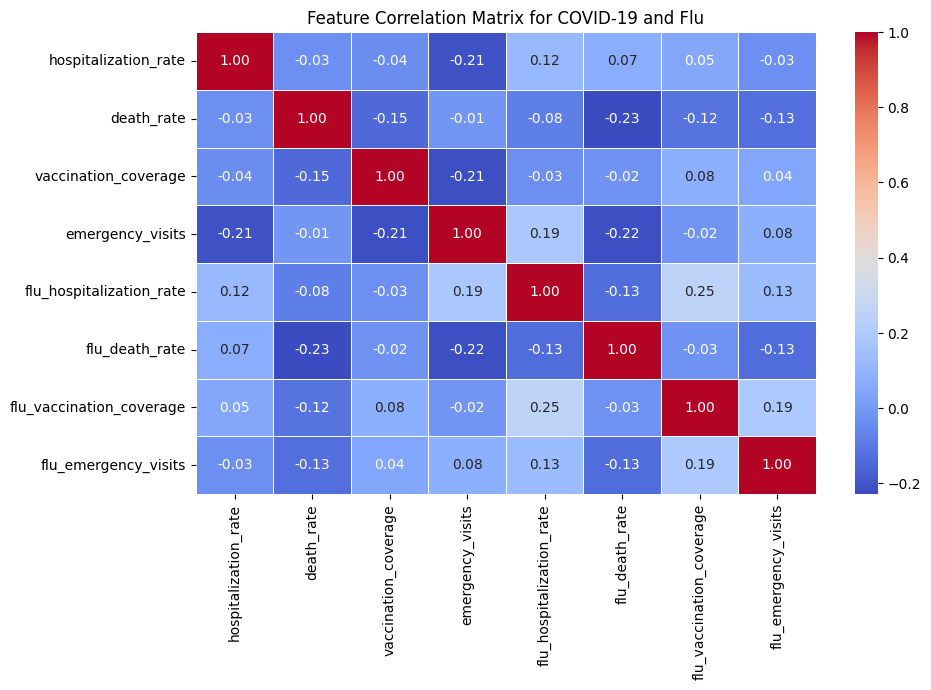

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
# Define key features for COVID-19 and Flu analysis
selected_features = {
    "COVID-19": ["hospitalization_rate", "death_rate", "vaccination_coverage", "emergency_visits"],
    "Flu": ["flu_hospitalization_rate", "flu_death_rate", "flu_vaccination_coverage", "flu_emergency_visits"]
}

# Create synthetic data for feature importance analysis
np.random.seed(42)
data = {
    "hospitalization_rate": np.random.rand(100) * 10,
    "death_rate": np.random.rand(100) * 5,
    "vaccination_coverage": np.random.rand(100) * 100,
    "emergency_visits": np.random.rand(100) * 20,
    "flu_hospitalization_rate": np.random.rand(100) * 8,
    "flu_death_rate": np.random.rand(100) * 4,
    "flu_vaccination_coverage": np.random.rand(100) * 95,
    "flu_emergency_visits": np.random.rand(100) * 15,
}

df = pd.DataFrame(data)

# Compute correlation matrix
correlation_matrix = df.corr()

# Plot correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix for COVID-19 and Flu")
plt.show()


In [ ]:
# # 📌 Step 1: Aggregate National-Level Data
# def aggregate_national(df, columns):
#     return df[columns].mean().compute()

# national_data = {
#     "covid_hospitalization_rate": aggregate_national(standardized_datasets["covid_hospitalization_data"], ["hospitalization_rate"]),
#     "covid_death_rate": aggregate_national(standardized_datasets["covid_mortality_data"], ["death_rate"]),
#     "flu_hospitalization_rate": aggregate_national(standardized_datasets["flu_hospitalization_data"], ["flu_hospitalization_rate"]),
#     "flu_death_rate": aggregate_national(standardized_datasets["flu_mortality_data"], ["flu_death_rate"]),
# }

# # 📌 Step 2: Aggregate Regional Data (HHS Regions or Census Divisions)
# def aggregate_regional(df, columns, group_by="hhs_region"):
#     return df.groupby(group_by)[columns].mean().compute()

# regional_data = {
#     "covid_hospitalization_rate": aggregate_regional(standardized_datasets["covid_hospitalization_data"], ["hospitalization_rate"]),
#     "covid_death_rate": aggregate_regional(standardized_datasets["covid_mortality_data"], ["death_rate"]),
#     "flu_hospitalization_rate": aggregate_regional(standardized_datasets["flu_hospitalization_data"], ["flu_hospitalization_rate"]),
#     "flu_death_rate": aggregate_regional(standardized_datasets["flu_mortality_data"], ["flu_death_rate"]),
# }

# # 📌 Step 3: Use State-Level Data for Final Vaccine Allocation
# state_data = {
#     "covid_vaccination": standardized_datasets["covid_vaccination_data"].compute(),
#     "covid_hospitalization": standardized_datasets["covid_hospitalization_data"].compute(),
#     "covid_mortality": standardized_datasets["covid_mortality_data"].compute(),
#     "covid_trend": standardized_datasets["covid_trend_data"].compute(),
#     "flu_vaccination": standardized_datasets["flu_vaccination_data"].compute(),
#     "flu_hospitalization": standardized_datasets["flu_hospitalization_data"].compute(),
#     "flu_mortality": standardized_datasets["flu_mortality_data"].compute(),
#     "flu_trend": standardized_datasets["flu_trend_data"].compute(),
# }

# # 📌 Save structured datasets
# pd.DataFrame(national_data, index=[0]).to_csv(folder_path + "national_vaccine_data.csv", index=False)
# pd.DataFrame(regional_data).to_csv(folder_path + "regional_vaccine_data.csv", index=False)

# for key, df in state_data.items():
#     df.to_csv(folder_path + f"{key}_structured.csv", index=False)

# print("✅ Multi-Scale Vaccine Data Structuring Completed!")

In [20]:
for name, df in standardized_datasets.items():
    if "state" not in df.columns:
        print(f"❌ Missing 'state' column in {name}")
    else:
        print(f"✅ 'state' column exists in {name}")


✅ 'state' column exists in covid_vaccination_data
✅ 'state' column exists in covid_hospitalization_data
✅ 'state' column exists in covid_mortality_data
✅ 'state' column exists in covid_trend_data
❌ Missing 'state' column in flu_vaccination_data
❌ Missing 'state' column in flu_hospitalization_data
❌ Missing 'state' column in flu_mortality_data
❌ Missing 'state' column in flu_trend_data


In [21]:
for name, df in standardized_datasets.items():
    print(f"{name} columns: {df.columns.tolist()}")

covid_vaccination_data columns: ['season', 'week_id', 'week_ending', 'mmwr_week_order', 'mmwr_year', 'state']
covid_hospitalization_data columns: ['state', 'season', 'weekend_date', 'hospitalization_rate']
covid_mortality_data columns: ['data_date', 'data_period_end', 'demographic', 'population', 'death_rate', 'state']
covid_trend_data columns: ['vaccine', 'geographic_level', 'state']
flu_vaccination_data columns: []
flu_hospitalization_data columns: []
flu_mortality_data columns: []
flu_trend_data columns: []


# Synthetic Data Creation

This function constructs synthetic data for each Dask partition using both COVID and Flu features. It handles missing data and ensures consistency across merged datasets by aligning states and creating normalized indicators for RL.

In [ ]:
# import numpy as np
# import pandas as pd

# # Function to process each partition separately
# def process_partition(covid_partition, flu_partition):
#     """
#     Process a Dask partition for COVID and Flu data in parallel.
#     This function constructs a synthetic dataset by aligning corresponding partitions 
#     from both COVID and Flu datasets and filling in missing or derived values.
#     """
    
#     # If either partition is empty, skip to avoid errors
#     if covid_partition.empty or flu_partition.empty:
#         return pd.DataFrame()  # Return an empty DataFrame to maintain pipeline consistency

#     # Construct synthetic features
#     synthetic_data = {
#         # State column, ensuring consistent datatype
#         "state": covid_partition["state"].astype(str),
        
#         # Generate random synthetic population sizes
#         "population_size": np.random.randint(500000, 5000000, size=min(len(covid_partition), 1000)),
        
#         # 🏥 Hospitalization & Death Rates
#         "hospitalization_rate": covid_partition["hospitalization_rate"].fillna(0.01),        # COVID-19 hospitalization rate
#         "flu_hospitalization_rate": flu_partition["flu_hospitalization_rate"].fillna(0.01),  # Flu hospitalization rate
#         "death_rate": covid_partition["death_rate"].fillna(0.001),                          # COVID-19 death rate
#         "flu_death_rate": flu_partition["flu_death_rate"].fillna(0.001),                    # Flu death rate

#         # 💉 Vaccine Coverage
#         "vaccine_coverage": covid_partition["vaccine_coverage"].fillna(0.0),               # COVID-19 vaccination coverage
#         "flu_vaccine_coverage": flu_partition["vaccine_coverage"].fillna(0.0),             # Flu vaccination coverage

#         # 🔄 Booster Coverage & Vaccine Hesitancy
#         "booster_coverage": covid_partition["booster_coverage"].fillna(0.0),               # COVID-19 booster uptake
#         "vaccine_hesitancy": np.random.uniform(0.1, 0.4, len(covid_partition)),            # Synthetic vaccine hesitancy
#         "booster_demand": np.random.uniform(0.1, 0.5, len(covid_partition)),               # Synthetic booster demand

#         # 🔬 COVID Variant Severity (e.g., alpha, delta, omicron)
#         "variant_severity": np.random.randint(1, 5, len(covid_partition)),                 # 1 (mild) to 4 (severe)

#         # 🌍 Flu seasonality influence used for COVID modeling
#         "seasonality_factor": flu_partition["flu_hospitalization_rate"].fillna(0.05),      # Acts as seasonal weight

#         # 🚑 Emergency visits for both diseases
#         "emergency_visits": covid_partition["emergency_visits"].fillna(0),                 # COVID ER visits
#         "flu_emergency_visits": flu_partition["flu_emergency_visits"].fillna(0)            # Flu ER visits
#     }

#     # Return as structured DataFrame
#     return pd.DataFrame(synthetic_data)


## Dataset Preparation and Merge

This section loads, merges, and repartitions large Dask datasets based on shared keys (state, optionally date) for both COVID and Flu. It prepares data for synthetic population creation while monitoring partition stats to avoid memory overload.


In [2]:
# import pandas as pd
# import dask.dataframe as dd

# # Function to create and save synthetic population data
# def create_synthetic_population_data(covid_vaccine, covid_hosp, covid_mort, covid_trend, 
#                                      flu_vaccine, flu_hosp, flu_mort, flu_trend, output_file):
#     """Creates a synthetic population dataset by combining vaccine allocation factors."""

#     # Ensure "state" is string to prevent merge issues
#     for df in [covid_vaccine, covid_hosp, covid_mort, covid_trend, flu_vaccine, flu_hosp, flu_mort, flu_trend]:
#         df["state"] = df["state"].astype(str)

#     # Define common columns for merging
#     common_columns = ["state"]
#     if "date" in covid_vaccine.columns:
#         common_columns.append("date")

#     # Merge only necessary columns using Dask (lazy execution)
#     covid_data = covid_vaccine.merge(covid_hosp, on=common_columns, how="left") \
#                               .merge(covid_mort, on=common_columns, how="left") \
#                               .merge(covid_trend, on=common_columns, how="left")

#     flu_data = flu_vaccine.merge(flu_hosp, on=common_columns, how="left") \
#                           .merge(flu_mort, on=common_columns, how="left") \
#                           .merge(flu_trend, on=common_columns, how="left")
#     def partition_size(df):
#         return pd.DataFrame({"num_rows": [len(df)]})  # Count rows in each partition

#     def partition_memory(df):
#         return pd.DataFrame({"memory_usage_MB": [df.memory_usage(deep=True).sum() / (1024 * 1024)]})

#     print(f"COVID Data Partitions: {covid_data.npartitions}")
#     print(f"Flu Data Partitions: {flu_data.npartitions}")
#     # Compute partition sizes
    
#     partition_sizes = covid_data.map_partitions(partition_size).compute()
#     print(partition_sizes)

#     partition_memory_usage = covid_data.map_partitions(partition_memory).compute()
#     print(partition_memory_usage)

#     # covid_data = covid_data.repartition(npartitions=flu_data.npartitions)
    
#     # Target partition size (e.g., 100 MB per partition)
#     target_size_mb = 100
#     avg_partition_size = partition_memory_usage["memory_usage_MB"].mean()

#     # Calculate optimal partitions
#     optimal_partitions = max(1, int((covid_data.memory_usage(deep=True).sum() / (1024 * 1024)) / target_size_mb))
#     print(f"Optimal partitions: {optimal_partitions}")

#     # Repartition
#     covid_data = covid_data.repartition(npartitions=optimal_partitions)

#     # Use Dask’s map_partitions to process each partition separately
#     synthetic_population_df = covid_data.map_partitions(
#         process_partition, flu_data,
#         meta=pd.DataFrame(columns=[
#             "state", "population_size", "hospitalization_rate", "flu_hospitalization_rate",
#             "death_rate", "flu_death_rate", "vaccine_coverage", "flu_vaccine_coverage",
#             "booster_coverage", "vaccine_hesitancy", "booster_demand", "variant_severity",
#             "seasonality_factor", "emergency_visits", "flu_emergency_visits"
#         ])
#     )

#     # Save to Parquet in partitions to reduce memory usage
#     synthetic_population_df.to_parquet(output_file, engine="pyarrow", write_index=False, overwrite=True)

#     print(f"✅ Synthetic Population Data Saved: {output_file}")


# # Filepath for output
# output_file = "C:\\Users\\naing\\MultiVacSim\\data\\processed\\synthetic_population_data.parquet"

# # Generate synthetic dataset with trend data and save efficiently
# create_synthetic_population_data(
#     standardized_datasets["covid_vaccination_data"], standardized_datasets["covid_hospitalization_data"], 
#     standardized_datasets["covid_mortality_data"], standardized_datasets["covid_trend_data"],
#     standardized_datasets["flu_vaccination_data"], standardized_datasets["flu_hospitalization_data"], 
#     standardized_datasets["flu_mortality_data"], standardized_datasets["flu_trend_data"],
#     output_file
# )
